<a href="https://colab.research.google.com/github/HarshaPriya03/PythonLearning/blob/main/RandomForestHandsOn_Aisha(05_04).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

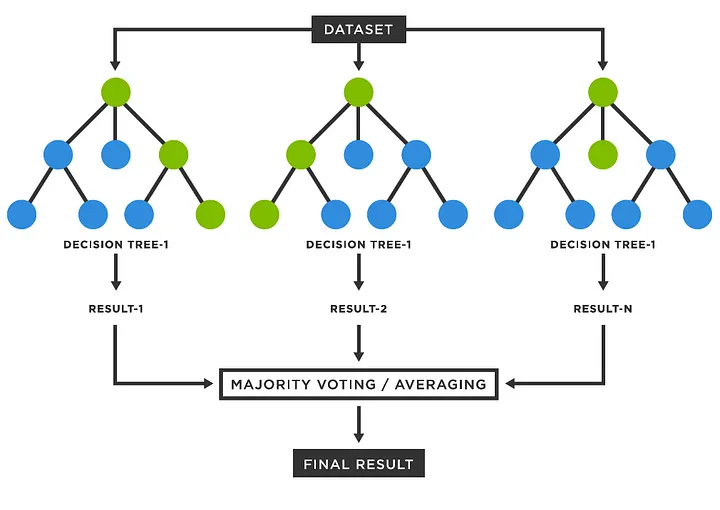

In [ ]:
#Dataset Link: https://drive.google.com/file/d/1nsnQPNTWbxNeXBXczDPIAMqvEyW_NHLR/view?usp=sharing

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/customer_churn_.csv')
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [ ]:
# customerID: A unique identifier for each customer.
# gender: The gender of the customer (Male/Female).
# SeniorCitizen: Indicates if the customer is a senior citizen (1 = Yes, 0 = No).
# Partner: Indicates if the customer has a partner (Yes/No).
# Dependents: Indicates if the customer has dependents (Yes/No).
# tenure: Number of months the customer has stayed with the company.
# PhoneService: Indicates if the customer has a phone service (Yes/No).
# MultipleLines: Indicates if the customer has multiple lines (Yes/No/No phone service).
# InternetService: Type of internet service (DSL, Fiber optic, None).
# OnlineSecurity: Indicates if the customer has online security add-ons (Yes/No/No internet service).
# DeviceProtection: Indicates if the customer has device protection add-ons (Yes/No/No internet service).
# TechSupport: Indicates if the customer has tech support add-ons (Yes/No/No internet service).
# StreamingTV: Indicates if the customer streams TV services (Yes/No/No internet service).
# StreamingMovies: Indicates if the customer streams movies (Yes/No/No internet service).
# Contract: Type of contract (Month-to-month, One year, Two year).
# PaperlessBilling: Indicates if the customer uses paperless billing (Yes/No).
# PaymentMethod: The payment method used (e.g., Electronic check, Mailed check, Bank transfer, Credit card).
# MonthlyCharges: Monthly charges for the customer.
# TotalCharges: Total charges billed to the customer.
# Churn: Indicates if the customer has churned (Yes/No).

In [ ]:
#EDA
# 1.null
# 2.duplicates
# 3.outliers
# 4.encoding

In [ ]:
#1. null
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
#2. duplicates
df.duplicated().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


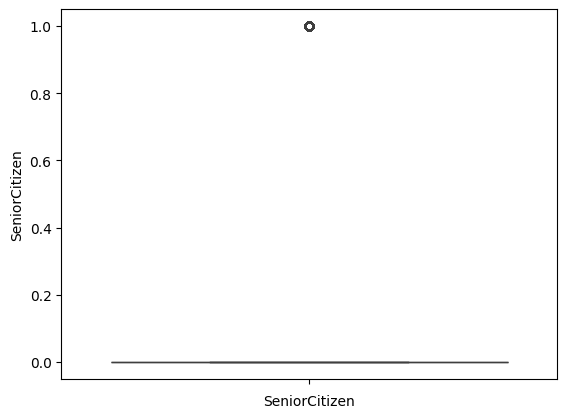

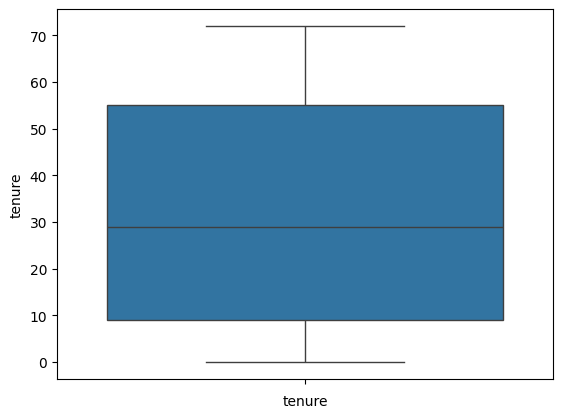

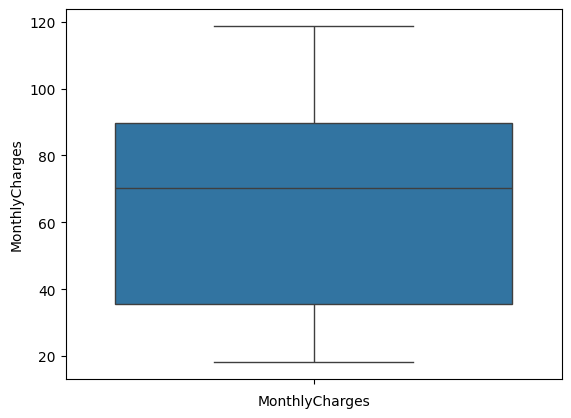

In [ ]:
#3. outlier

for i in df.columns:
  if(df[i].dtype!='object'):
    sns.boxplot(df[i])
    plt.xlabel(i)
    plt.show()

# no boxplot visible = dont remove outliers

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
# df['TotalCharges']=df['TotalCharges'].astype(float) #will throw an error as there is unconvertable data in the column
df['TotalCharges']=pd.to_numeric(df['TotalCharges'], errors='coerce') #whenever we face any unconvertable value, we replace it will null

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [ ]:
df.drop(['customerID'], axis=1, inplace=True)

In [ ]:
#4. Label Encoding

from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()

for col in df.columns:
  if(df[col].dtype == 'object'):
    df[col]=le.fit_transform(df[col])

 #le.classes_=categories, range(len(le.classes_))= encoded value(0,1...)
 #zip pairs category with its encoded value
    for category, encoded_val in zip(le.classes_,range(len(le.classes_))):
      print(f"{category} -> {encoded_val}")

Female -> 0
Male -> 1
No -> 0
Yes -> 1
No -> 0
Yes -> 1
No -> 0
Yes -> 1
No -> 0
No phone service -> 1
Yes -> 2
DSL -> 0
Fiber optic -> 1
No -> 2
No -> 0
No internet service -> 1
Yes -> 2
No -> 0
No internet service -> 1
Yes -> 2
No -> 0
No internet service -> 1
Yes -> 2
No -> 0
No internet service -> 1
Yes -> 2
No -> 0
No internet service -> 1
Yes -> 2
No -> 0
No internet service -> 1
Yes -> 2
Month-to-month -> 0
One year -> 1
Two year -> 2
No -> 0
Yes -> 1
Bank transfer (automatic) -> 0
Credit card (automatic) -> 1
Electronic check -> 2
Mailed check -> 3
No -> 0
Yes -> 1


In [ ]:
#Research about .classes_ and draft a code that prints "category -> encoded value" at the time of label encoding

In [ ]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,2,0,2,0,2,2,2,2,1,1,3,84.80,1990.50,0
7039,0,0,1,1,72,1,2,1,0,2,2,0,2,2,1,1,1,103.20,7362.90,0
7040,0,0,1,1,11,0,1,0,2,0,0,0,0,0,0,1,2,29.60,346.45,0
7041,1,1,1,0,4,1,2,1,0,0,0,0,0,0,0,1,3,74.40,306.60,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   int64  
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   int64  
 3   Dependents        7032 non-null   int64  
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   int64  
 6   MultipleLines     7032 non-null   int64  
 7   InternetService   7032 non-null   int64  
 8   OnlineSecurity    7032 non-null   int64  
 9   OnlineBackup      7032 non-null   int64  
 10  DeviceProtection  7032 non-null   int64  
 11  TechSupport       7032 non-null   int64  
 12  StreamingTV       7032 non-null   int64  
 13  StreamingMovies   7032 non-null   int64  
 14  Contract          7032 non-null   int64  
 15  PaperlessBilling  7032 non-null   int64  
 16  PaymentMethod     7032 non-null   int64  
 17  

In [ ]:
#Model Building
# 1.spliting the data(x and y)
# 2.splitting the data into training and testing sets
# 3.training
# 4.testing
# 5.evaluation

In [ ]:
x=df.iloc[:,:-1] #features; iloc[:,:-1] : all rows, all columns except last
y=df['Churn']

In [ ]:
x

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,2,0,2,0,2,2,2,2,1,1,3,84.80,1990.50
7039,0,0,1,1,72,1,2,1,0,2,2,0,2,2,1,1,1,103.20,7362.90
7040,0,0,1,1,11,0,1,0,2,0,0,0,0,0,0,1,2,29.60,346.45
7041,1,1,1,0,4,1,2,1,0,0,0,0,0,0,0,1,3,74.40,306.60


In [ ]:
y

,Churn
0,0
1,0
2,1
3,0
4,1
...,...
7038,0
7039,0
7040,0
7041,1


In [ ]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20, random_state=42)

In [ ]:
x_train

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
6030,0,0,0,0,43,0,1,0,0,0,2,0,2,2,0,1,0,49.05,2076.20
3410,1,0,0,0,3,1,0,0,0,0,0,0,2,0,0,0,1,53.40,188.70
5483,0,0,1,0,55,1,2,1,0,0,2,0,0,0,0,1,2,77.75,4458.15
5524,1,0,1,1,45,1,0,0,2,0,0,2,0,0,2,0,0,54.65,2553.70
6337,0,0,1,1,55,1,2,1,2,0,0,0,2,2,1,0,3,100.90,5448.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3778,1,0,0,0,3,1,2,0,0,0,0,0,0,0,0,0,0,50.40,137.25
5199,0,0,0,0,51,1,2,1,0,2,2,2,2,2,1,1,2,111.50,5703.25
5235,1,0,0,0,9,1,2,1,2,0,0,0,0,0,0,1,2,81.15,784.45
5399,0,0,0,0,50,1,0,2,1,1,1,1,1,1,1,0,0,19.75,989.05


In [ ]:
x_test

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
2481,1,1,1,0,61,1,2,2,1,1,1,1,1,1,2,0,0,25.00,1501.75
6784,0,0,0,0,19,1,2,2,1,1,1,1,1,1,0,0,0,24.70,465.85
6125,1,0,1,0,13,1,2,1,0,0,2,0,2,2,0,1,1,102.25,1359.00
3052,1,0,1,0,37,1,2,0,2,0,0,0,0,0,0,1,3,55.05,2030.75
4099,0,0,0,0,6,0,1,0,2,0,0,0,0,0,0,0,0,29.45,161.45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1733,1,0,0,0,1,1,0,2,1,1,1,1,1,1,0,0,3,19.05,19.05
5250,1,0,0,0,12,1,2,1,0,0,0,0,2,2,0,0,2,94.55,1173.55
5465,0,0,0,0,26,1,0,0,0,2,2,0,0,0,1,1,3,56.05,1553.20
5851,0,1,0,0,35,1,2,1,2,2,2,2,2,2,1,1,0,110.80,3836.30


In [ ]:
y_train

,Churn
6030,1
3410,1
5483,1
5524,0
6337,0
...,...
3778,0
5199,0
5235,0
5399,0


In [ ]:
y_test

,Churn
2481,0
6784,0
6125,1
3052,0
4099,0
...,...
1733,0
5250,0
5465,0
5851,0


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model=RandomForestClassifier()

model.fit(x_train,y_train)

RandomForestClassifier()

In [ ]:
y_pred=model.predict(x_test)

In [ ]:
y_pred

array([0, 0, 1, ..., 0, 0, 0])

In [ ]:
from sklearn.metrics import * #import * = import everything

accuracy_score(y_test,y_pred)

0.783226723525231

In [ ]:
#Parameters are values derived from the dataset
#Example: Linear regression: the model itself assigns the m and c
#Hyperparameters are values usually given by the programmer
#Example: max_depth...

In [ ]:
#HYPERPARAMETER TUNING

In [ ]:
n_est=[50,100,150,200,250,300,350,400,450,500,550,600,650]

In [ ]:
#n_estimator: number of decision trees in a forest
for i in n_est:
  temp_model=RandomForestClassifier(n_estimators=i, random_state=23) #,oob_score=True)
  temp_model.fit(x_train,y_train)
  y_temp_pred=temp_model.predict(x_test)
  acc=accuracy_score(y_test,y_temp_pred)
  # oob_res=temp_model.oob_score_
  print(f"The accuracy of n_estimator {i} is {acc}")
  # print(oob_res)

The accuracy of n_estimator 50 is 0.7867803837953091
The accuracy of n_estimator 100 is 0.7839374555792467
The accuracy of n_estimator 150 is 0.7917555081734187
The accuracy of n_estimator 200 is 0.7938877043354655
The accuracy of n_estimator 250 is 0.7938877043354655
The accuracy of n_estimator 300 is 0.7945984363894811
The accuracy of n_estimator 350 is 0.7931769722814499
The accuracy of n_estimator 400 is 0.7910447761194029
The accuracy of n_estimator 450 is 0.7917555081734187
The accuracy of n_estimator 500 is 0.7917555081734187
The accuracy of n_estimator 550 is 0.7924662402274343
The accuracy of n_estimator 600 is 0.7910447761194029
The accuracy of n_estimator 650 is 0.7903340440653873


1. n_est: more people giving opinions = more reliable decisions
  - 10 trees -> weak decision
  - 300 trees -> strong decision

2. min_samples_split: minimum data required to split a node
  - dont make decisions on too little data
    - small value -> splits a lot -> overfitting
    - large value -> fewer splits -> generalization

3. min_samples_leaf: minimum data in a leaf node

4. criterion: method to decide the best split


In [ ]:
#param : dictionary storing hyperparameters with random values
param={
    "n_estimators": [100,200,300],
    "max_depth": [1,5,10],
    "min_samples_split": [2,5,7], #min samples requires to split a node
    "min_samples_leaf": [1,2,4], #min samples required to call a node as leaf
    "criterion": ['gini', 'entropy']
}

In [ ]:
#WE CANNOT TRY EVERY COMBINATION MANUALLY
#GridSearchCrossValidation: creates ALL possible combinations of parameters, tests it to give you the best output

In [ ]:
from sklearn.model_selection import GridSearchCV

#defining base model based on which we select best parameters
base_model=RandomForestClassifier(random_state=23)

#initializing the grid search model with RF as its base
grid_search=GridSearchCV(estimator=base_model, param_grid=param)

In [ ]:
grid_search.fit(x_train,y_train)

In [ ]:
print(grid_search.best_params_)

In [ ]:
final_model=RandomForestClassifier(n_estimators=100,criterion='entropy',max_depth=10, min_samples_split=2, min_samples_leaf=4, random_state=23)

In [ ]:
final_model.fit(x_train,y_train)

In [ ]:
y_pred_final=final_model.predict(x_test)

In [ ]:
accuracy_score(y_test,y_pred_final)